# Notebook 07 — Conformal Prediction avec MAPIE v1
**SplitConformalClassifier · Intervalles garantis à 90 % et 95 %**

> ⚠️ Ce notebook utilise l'**API MAPIE v1+** (`SplitConformalClassifier`).
> La classe `MapieClassifier` a été supprimée depuis MAPIE 1.0.
>
> Pour vérifier votre version : `pip show mapie`

In [1]:
# ── Vérification version MAPIE ───────────────────────────────────────────────
import importlib.metadata, warnings
warnings.filterwarnings('ignore')

mapie_version = importlib.metadata.version('mapie')
print(f'MAPIE version installée : {mapie_version}')

major = int(mapie_version.split('.')[0])
if major < 1:
    print('⚠️  Vous utilisez MAPIE < 1.0. Ce notebook nécessite MAPIE >= 1.0')
    print('   Exécutez : pip install mapie --upgrade')
else:
    print('✅ MAPIE >= 1.0 détecté — bonne version')

MAPIE version installée : 1.3.0
✅ MAPIE >= 1.0 détecté — bonne version


In [12]:
# ── Imports ──────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
sns.set_theme(style='whitegrid', palette='Set2')

# ✅ MAPIE v1 — nouveaux imports
from mapie.classification import SplitConformalClassifier
# Note : CrossConformalClassifier est disponible si vous préférez cross-conformal

# Métriques MAPIE v1
# coverage_score remplace classification_coverage_score
# mean_width_score remplace classification_mean_width_score
from mapie.metrics.classification import classification_coverage_score, classification_mean_width_score

# sklearn
from sklearn.metrics import roc_auc_score, brier_score_loss, classification_report
from sklearn.model_selection import train_test_split
from sklearn.calibration import CalibratedClassifierCV

# LightGBM (modèle de base)
import lightgbm as lgb
import joblib

print('✅ Imports OK')

✅ Imports OK


## 1. Chargement du modèle et des données

In [14]:
# ── Charger le dataset nettoyé ────────────────────────────────────────────────
try:
    df = pd.read_parquet('../data/processed/lending_clean.parquet')
    print(f'✅ Dataset chargé : {df.shape}')
except FileNotFoundError:
    df = pd.read_csv('../data/processed/lending_clean.csv', low_memory=False)
    print(f'✅ Dataset chargé depuis CSV : {df.shape}')

# ── Charger le modèle LightGBM entraîné dans notebook 04 ────────────────────
try:
    lgbm_model = joblib.load('../models/lgbm_model.pkl')
    print('✅ Modèle LightGBM chargé')
except FileNotFoundError:
    print('⚠️  Modèle non trouvé, entraînement d\'un modèle de base...')
    lgbm_model = None

✅ Dataset chargé : (1345310, 115)
⚠️  Modèle non trouvé, entraînement d'un modèle de base...


In [16]:
print(df.columns.tolist())

['loan_amnt', 'funded_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'pymnt_plan', 'purpose', 'title', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'collections_12_mths_ex_med', 'application_type', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'total_rev_hi_lim', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'chargeoff_within_12_mths', 'delinq_amnt', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc', 'mths_since_recent_bc', 'mths_since_recent_inq', 'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_actv_rev_tl', 'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl', 'num_rev_accts', 'num_rev_tl_bal_gt_0', 'num_sats', 'num_tl_120dpd_2m', 'num_t

In [17]:
# ── Préparation des features ──────────────────────────────────────────────────
TARGET = 'target'

# Colonnes à exclure
drop_cols = [
    TARGET, 'loan_status', 'issue_d', 'last_pymnt_d', 'earliest_cr_line',
    'duration_months', 'grade_label'
]
feature_cols = [
    c for c in df.columns
    if c not in drop_cols
    and df[c].dtype in [np.float64, np.float32, np.int64, np.int32, 'int64', 'float64']
]

X = df[feature_cols].fillna(df[feature_cols].median())
y = df[TARGET]

print(f'Features : {len(feature_cols)}')
print(f'Target distribution :\n{y.value_counts(normalize=True).round(3)}')

Features : 99
Target distribution :
target
0    0.8
1    0.2
Name: proportion, dtype: float64


In [18]:
# ── Split : train / conformalization / test ───────────────────────────────────
# ⚠️ IMPORTANT pour MAPIE v1 :
#   On a besoin de 3 ensembles distincts :
#   1. X_train      → entraîner le classifieur de base
#   2. X_conf       → conformalize() : estimer les scores de conformité
#   3. X_test       → évaluer la couverture garantie

X_trainconf, X_test, y_trainconf, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)
X_train, X_conf, y_train, y_conf = train_test_split(
    X_trainconf, y_trainconf,
    test_size=0.25, random_state=42, stratify=y_trainconf
)

print(f'Train       : {X_train.shape}')
print(f'Conformalize: {X_conf.shape}')
print(f'Test        : {X_test.shape}')

Train       : (857634, 99)
Conformalize: (285879, 99)
Test        : (201797, 99)


## 2. Entraînement du classifieur de base

In [19]:
# ── LightGBM si pas déjà chargé ──────────────────────────────────────────────
if lgbm_model is None:
    lgbm_model = lgb.LGBMClassifier(
        n_estimators    = 500,
        learning_rate   = 0.05,
        num_leaves      = 63,
        min_child_samples = 50,
        subsample       = 0.8,
        colsample_bytree= 0.8,
        class_weight    = 'balanced',
        n_jobs          = -1,
        random_state    = 42,
        verbose         = -1
    )
    lgbm_model.fit(X_train, y_train)
    print('✅ LightGBM entraîné')

# Performance de base
y_prob_test = lgbm_model.predict_proba(X_test)[:, 1]
print(f'AUC-ROC  : {roc_auc_score(y_test, y_prob_test):.4f}')
print(f'Brier    : {brier_score_loss(y_test, y_prob_test):.4f}')

✅ LightGBM entraîné
AUC-ROC  : 0.7278
Brier    : 0.2084


## 3. Conformal Prediction — API MAPIE v1

### Correspondance ancienne → nouvelle API

| MAPIE ≤ 0.9 (ancienne) | MAPIE v1+ (nouvelle) |
|---|---|
| `MapieClassifier(estimator, cv='prefit')` | `SplitConformalClassifier(estimator, prefit=True)` |
| `mapie.fit(X_cal, y_cal)` | `mapie.conformalize(X_conf, y_conf)` |
| `mapie.predict(X, alpha=[0.1, 0.05])` | `mapie.predict_set(X)` |
| `alpha=0.1` → 90% | `confidence_level=0.9` |
| `classification_coverage_score` | `coverage_score` |

In [20]:
# ── 3.1 Conformal Prediction à 90% et 95% ────────────────────────────────────
# SplitConformalClassifier avec prefit=True (modèle déjà entraîné)

CONFIDENCE_LEVELS = [0.90, 0.95]   # équivalent alpha = [0.10, 0.05]

mapie = SplitConformalClassifier(
    estimator       = lgbm_model,
    confidence_level= CONFIDENCE_LEVELS,   # Liste = plusieurs niveaux d'un coup
    conformity_score= 'lac',               # Least Ambiguous set-valued Classifier
    prefit          = True,                # modèle déjà entraîné → pas de re-fit
    random_state    = 42
)

# ✅ conformalize() remplace l'ancien .fit() pour SplitConformal
mapie.conformalize(X_conf, y_conf)
print('✅ Conformalisation terminée')

# ✅ predict_set() remplace l'ancien .predict()
# Retourne : (y_pred, y_pred_sets)
# y_pred_sets.shape = (n_samples, n_classes, n_confidence_levels)
y_pred, y_pred_sets = mapie.predict_set(X_test)

print(f'Shape y_pred_sets : {y_pred_sets.shape}')
print(f'  → (n_samples={y_pred_sets.shape[0]}, n_classes=2, n_levels={y_pred_sets.shape[2]})')

✅ Conformalisation terminée
Shape y_pred_sets : (201797, 2, 2)
  → (n_samples=201797, n_classes=2, n_levels=2)


In [23]:
# ── 3.2 Métriques de couverture ───────────────────────────────────────────────
print('=' * 55)
print(f'{"Niveau":>10} | {"Coverage observée":>18} | {"Width moyenne":>13}')
print('-' * 55)

for i, level in enumerate(CONFIDENCE_LEVELS):
    sets_i  = y_pred_sets[:, :, i]   # shape (n_samples, n_classes)

    # coverage_score : proportion de fois où le vrai label est dans le set
    #cov = classification_coverage_score(y_test.values, sets_i)

    # Largeur moyenne du set (nombre moyen de classes dans le set)
    #width = sets_i.sum(axis=1).mean()

    cov = classification_coverage_score(y_test.values, sets_i).mean()
    width = float(sets_i.sum(axis=1).mean())
    
    ok = '✅' if abs(cov - level) < 0.04 else '⚠️ '
    print(f'{level*100:.0f}%       | {cov:.4f} ({cov*100:.1f}%)        | {width:.4f}       {ok}')

print('=' * 55)
print('Couverture cible 90% → doit être entre 88% et 92%')
print('Couverture cible 95% → doit être entre 93% et 97%')

    Niveau |  Coverage observée | Width moyenne
-------------------------------------------------------
90%       | 0.9002 (90.0%)        | 1.5541       ✅
95%       | 0.9509 (95.1%)        | 1.7154       ✅
Couverture cible 90% → doit être entre 88% et 92%
Couverture cible 95% → doit être entre 93% et 97%


In [24]:
# ── 3.3 Analyse des zones de décision ────────────────────────────────────────
# Classifier les prédictions en 3 zones :
#   SÛR     : set de taille 1 (une seule classe prédite)
#   GRIS    : set de taille 2 (les deux classes incluses = incertain)
#   VIDE    : set de taille 0 (très rare)

sets_90 = y_pred_sets[:, :, 0]   # niveau 90%
set_sizes = sets_90.sum(axis=1)

n_sure  = (set_sizes == 1).sum()
n_grey  = (set_sizes == 2).sum()
n_empty = (set_sizes == 0).sum()
n_total = len(set_sizes)

print('Analyse des zones de décision (niveau 90%) :')
print(f'  🟢 Zone sûre  (set size=1) : {n_sure:>8,}  ({n_sure/n_total:.1%})')
print(f'  🟡 Zone grise (set size=2) : {n_grey:>8,}  ({n_grey/n_total:.1%})')
print(f'  ⬜ Set vide   (set size=0) : {n_empty:>8,}  ({n_empty/n_total:.1%})')
print()
print(f'⚡ {n_grey/n_total:.1%} des clients tombent en zone grise → action humaine recommandée')

Analyse des zones de décision (niveau 90%) :
  🟢 Zone sûre  (set size=1) :   89,985  (44.6%)
  🟡 Zone grise (set size=2) :  111,812  (55.4%)
  ⬜ Set vide   (set size=0) :        0  (0.0%)

⚡ 55.4% des clients tombent en zone grise → action humaine recommandée


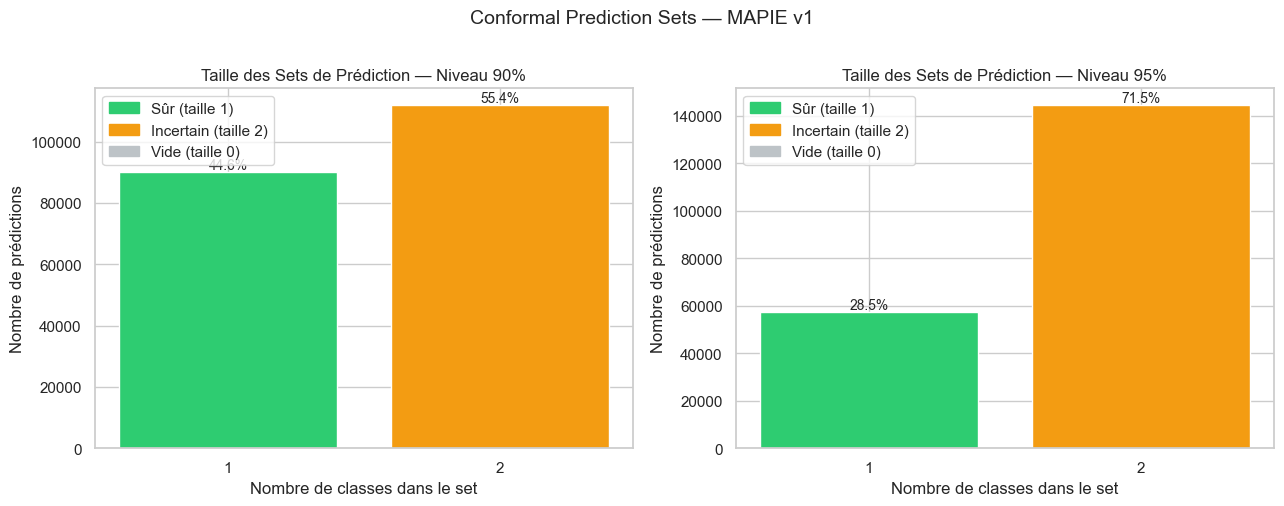

In [25]:
# ── 3.4 Visualisation : Distribution des tailles de sets ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

level_labels = ['90%', '95%']
for i, (level, label, ax) in enumerate(zip(CONFIDENCE_LEVELS, level_labels, axes)):
    sizes = y_pred_sets[:, :, i].sum(axis=1)
    counts = pd.Series(sizes).value_counts().sort_index()

    colors = ['#2ECC71' if s == 1 else '#F39C12' if s == 2 else '#BDC3C7' for s in counts.index]
    bars = ax.bar(counts.index.astype(str), counts.values, color=colors, edgecolor='white')

    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                f'{v/n_total:.1%}', ha='center', va='bottom', fontsize=10)

    ax.set_title(f'Taille des Sets de Prédiction — Niveau {label}', fontsize=12)
    ax.set_xlabel('Nombre de classes dans le set')
    ax.set_ylabel('Nombre de prédictions')

    handles = [
        mpatches.Patch(color='#2ECC71', label='Sûr (taille 1)'),
        mpatches.Patch(color='#F39C12', label='Incertain (taille 2)'),
        mpatches.Patch(color='#BDC3C7', label='Vide (taille 0)'),
    ]
    ax.legend(handles=handles)

plt.suptitle('Conformal Prediction Sets — MAPIE v1', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

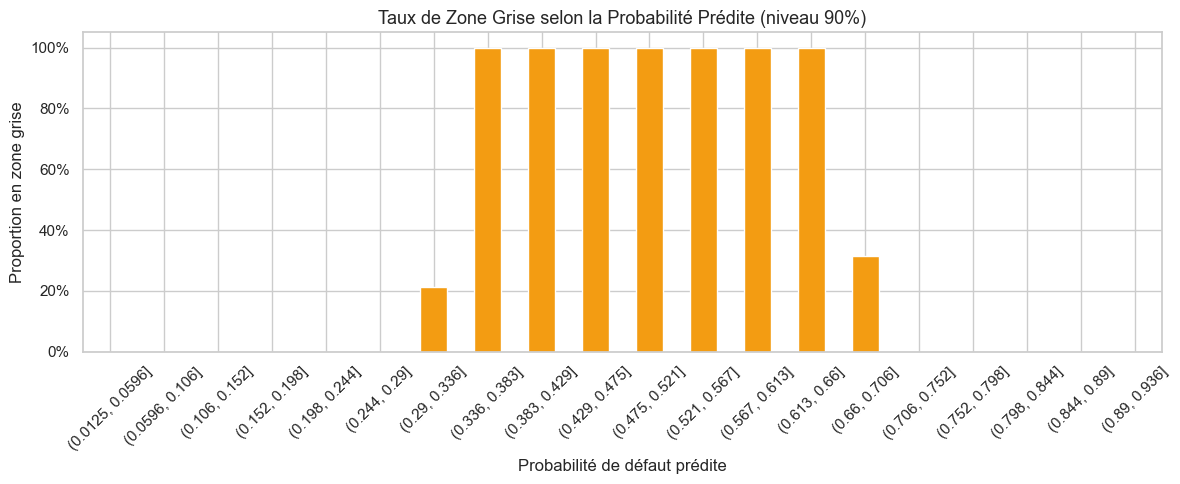

📌 Interprétation : les clients avec proba ≈ 0.3-0.6 tombent le plus souvent en zone grise.
   → Pour ces clients, l'analyste humain doit intervenir.


In [26]:
# ── 3.5 Connexion probabilités ↔ sets ────────────────────────────────────────
# Montrer que les clients avec proba ~0.5 tombent dans la zone grise

y_prob = lgbm_model.predict_proba(X_test)[:, 1]
sizes_90 = y_pred_sets[:, :, 0].sum(axis=1)

prob_bins = pd.cut(y_prob, bins=20)
grey_rate = pd.DataFrame({'bin': prob_bins, 'grey': sizes_90 == 2}).groupby('bin')['grey'].mean()

fig, ax = plt.subplots(figsize=(12, 5))
grey_rate.plot.bar(ax=ax, color='#F39C12', edgecolor='white')
ax.set_title('Taux de Zone Grise selon la Probabilité Prédite (niveau 90%)', fontsize=13)
ax.set_xlabel('Probabilité de défaut prédite')
ax.set_ylabel('Proportion en zone grise')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

print('📌 Interprétation : les clients avec proba ≈ 0.3-0.6 tombent le plus souvent en zone grise.')
print('   → Pour ces clients, l\'analyste humain doit intervenir.')

## 4. Application Crédit — Décision Automatique

In [27]:
def credit_decision(x_client: pd.DataFrame, mapie_model, base_model,
                    level_idx: int = 0) -> dict:
    """
    Retourne la décision crédit pour un client.

    Paramètres
    ----------
    x_client   : DataFrame d'une ligne (features du client)
    mapie_model: SplitConformalClassifier déjà conformalisé
    base_model : le classifieur LightGBM (pour la proba)
    level_idx  : 0 → 90%, 1 → 95%

    Retourne
    --------
    dict avec : proba, set_size, decision, message
    """
    proba      = base_model.predict_proba(x_client)[0, 1]
    _, pred_set = mapie_model.predict_set(x_client)
    set_size   = pred_set[0, :, level_idx].sum()

    if set_size == 0:
        decision = 'REFUSER'
        message  = 'Set vide — risque maximal'
    elif set_size == 1:
        if pred_set[0, 0, level_idx]:   # classe 0 = pas de défaut
            decision = 'ACCEPTER'
            message  = f'Modèle confiant : proba défaut = {proba:.1%}'
        else:
            decision = 'REFUSER'
            message  = f'Défaut prédit avec certitude : proba = {proba:.1%}'
    else:   # set_size == 2
        decision = 'DEMANDER DOCUMENTS'
        message  = f'Zone grise : proba défaut = {proba:.1%} — incertitude élevée'

    return {
        'probabilite_defaut': f'{proba:.1%}',
        'set_size'          : int(set_size),
        'decision'          : decision,
        'message'           : message
    }


# Test sur 3 clients
print('=== Décisions Conformal (niveau 90%) ===\n')
for i in [0, 1, 2]:
    client = X_test.iloc[[i]]
    result = credit_decision(client, mapie, lgbm_model, level_idx=0)
    print(f'Client {i+1}:')
    for k, v in result.items():
        print(f'  {k:25s}: {v}')
    print()

=== Décisions Conformal (niveau 90%) ===

Client 1:
  probabilite_defaut       : 66.7%
  set_size                 : 2
  decision                 : DEMANDER DOCUMENTS
  message                  : Zone grise : proba défaut = 66.7% — incertitude élevée

Client 2:
  probabilite_defaut       : 12.0%
  set_size                 : 1
  decision                 : ACCEPTER
  message                  : Modèle confiant : proba défaut = 12.0%

Client 3:
  probabilite_defaut       : 38.6%
  set_size                 : 2
  decision                 : DEMANDER DOCUMENTS
  message                  : Zone grise : proba défaut = 38.6% — incertitude élevée



## 5. Comparaison : CrossConformalClassifier (Alternative)

In [29]:
# CrossConformalClassifier = l'équivalent de MapieClassifier avec cv=5
# Plus robuste mais plus lent (entraîne k modèles)
from mapie.classification import CrossConformalClassifier

# Utiliser un sous-ensemble pour la vitesse
SAMPLE_CC = min(50_000, len(X_train))

mapie_cross = CrossConformalClassifier(
    estimator        = lgb.LGBMClassifier(
        n_estimators=200, learning_rate=0.05,
        num_leaves=31, n_jobs=-1, verbose=-1, random_state=42
    ),
    confidence_level = 0.90,
    cv               = 5,
    random_state     = 42
)

# fit_conformalize remplace fit() pour le cross-conformal
X_cc = X_train.iloc[:SAMPLE_CC]
y_cc = y_train.iloc[:SAMPLE_CC]

mapie_cross.fit_conformalize(X_cc, y_cc)
print('✅ CrossConformalClassifier entraîné')

# Prédictions
_, y_sets_cross = mapie_cross.predict_set(X_test)

cov_cross = classification_coverage_score(y_test.values, y_sets_cross[:, :, 0]).mean()
width_cross = y_sets_cross[:, :, 0].sum(axis=1).mean()

print(f'\nCrossConformal (90%) :')
print(f'  Coverage : {cov_cross:.4f} ({cov_cross*100:.1f}%)')
print(f'  Width    : {width_cross:.4f}')

✅ CrossConformalClassifier entraîné

CrossConformal (90%) :
  Coverage : 0.9022 (90.2%)
  Width    : 1.2764


In [30]:
# ── Tableau comparatif Split vs Cross ────────────────────────────────────────
cov_split = classification_coverage_score(y_test.values, y_pred_sets[:, :, 0]).mean()
width_split = y_pred_sets[:, :, 0].sum(axis=1).mean()

comp = pd.DataFrame({
    'Méthode'           : ['SplitConformal', 'CrossConformal'],
    'Coverage@90%'      : [f'{cov_split:.4f}', f'{cov_cross:.4f}'],
    'Width moyenne'     : [f'{width_split:.4f}', f'{width_cross:.4f}'],
    'Vitesse'           : ['Rapide (1 split)', 'Lent (5 folds)'],
    'Recommandé pour'   : ['Production', 'Recherche'],
})
display(comp)

,Méthode,Coverage@90%,Width moyenne,Vitesse,Recommandé pour
0,SplitConformal,0.9002,1.5541,Rapide (1 split),Production
1,CrossConformal,0.9022,1.2764,Lent (5 folds),Recherche


## 6. Export

In [31]:
import os
os.makedirs('../models', exist_ok=True)

joblib.dump(mapie,       '../models/mapie_split_model.pkl')
joblib.dump(mapie_cross, '../models/mapie_cross_model.pkl')

# Sauvegarder aussi les feature names pour le dashboard
import json
with open('../models/feature_cols.json', 'w') as f:
    json.dump(list(X_train.columns), f)

print('✅ Modèles MAPIE v1 exportés :')
print('  - ../models/mapie_split_model.pkl   (SplitConformalClassifier)')
print('  - ../models/mapie_cross_model.pkl   (CrossConformalClassifier)')
print('  - ../models/feature_cols.json')

✅ Modèles MAPIE v1 exportés :
  - ../models/mapie_split_model.pkl   (SplitConformalClassifier)
  - ../models/mapie_cross_model.pkl   (CrossConformalClassifier)
  - ../models/feature_cols.json
